# 07 - Statistical Deep Dive: Rentals Dataset

## 📌 Objective
This notebook performs advanced statistical diagnostics on the Rentals dataset. We focus on heteroscedasticity, non-parametric variance testing, and baseline feature importance to confirm the "Pre-Model" quality of our 6-city rental expansion.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from sklearn.ensemble import RandomForestRegressor

%matplotlib inline
sns.set_theme(style="whitegrid", palette="magma")

# Load Model-Ready Rentals Data
df = pd.read_parquet("../data/model/model_rentals.parquet")
print(f"🔹 Auditing {len(df):,} Rental Records")

🔹 Auditing 25,293 Rental Records


## 1. Heteroscedasticity Diagnostic
In real estate, variance often grows with property size (Heteroscedasticity). We use the **Breusch-Pagan** test to evaluate this. If variance is not constant, it further justifies the use of a Log-transformation.

Breusch-Pagan Test p-value: 0.0000
Result: Heteroscedasticity Detected


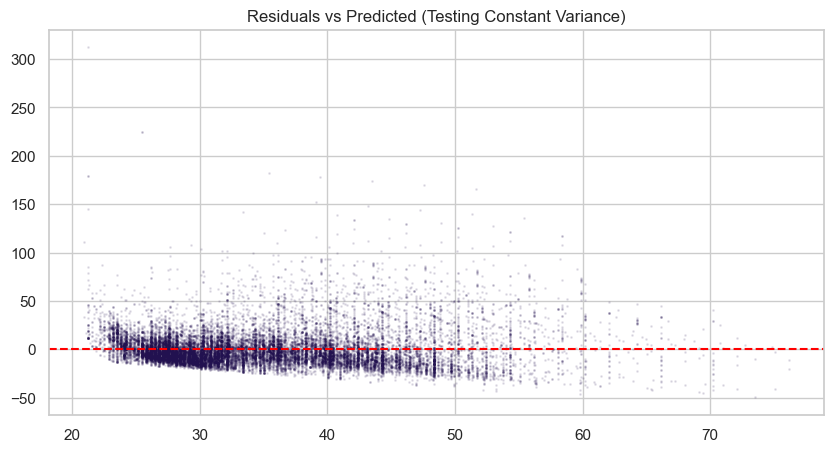

In [2]:
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.formula.api import ols

# Simple OLS for diagnostics
model = ols('price_per_sqft ~ area + bedrooms + bathrooms', data=df.dropna()).fit()
_, p_val, _, _ = het_breuschpagan(model.resid, model.model.exog)

print(f"Breusch-Pagan Test p-value: {p_val:.4f}")
print("Result: " + ("Heteroscedasticity Detected" if p_val < 0.05 else "Homoscedasticity Confirmed"))

# Visual check
plt.figure(figsize=(10, 5))
plt.scatter(model.predict(), model.resid, alpha=0.1, s=1)
plt.axhline(0, color='red', linestyle='--')
plt.title("Residuals vs Predicted (Testing Constant Variance)")
plt.show()

## 2. Market Variance (Kruskal-Wallis)
Since rental data can have non-normal distributions, we use the non-parametric **Kruskal-Wallis H-test** to verify if the median rent differs significantly by city.

In [3]:
groups = [group['price_per_sqft'].values for name, group in df.groupby('city')]
h_stat, p_val = stats.kruskal(*groups)
print(f"Kruskal-Wallis H-statistic: {h_stat:.2f}, p-value: {p_val:.4f}")

Kruskal-Wallis H-statistic: 11182.77, p-value: 0.0000


## 3. Baseline Feature Importance
A "Sanity Check" model (Random Forest) to verify that our features (Area, H3 Median) have high information gain before we run the expensive Optuna tuning.

C:\Users\Asus\AppData\Local\Temp\ipykernel_26160\2861944959.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rf.feature_importances_, y=X.columns, palette='magma')


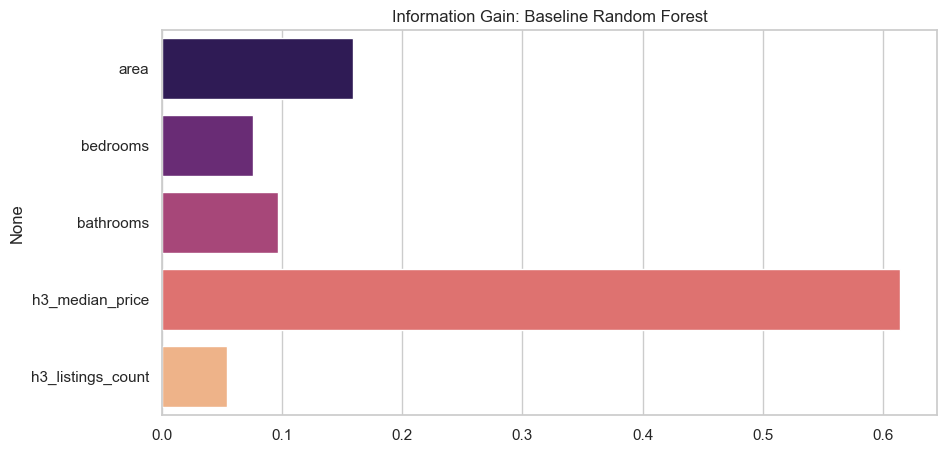

In [4]:
from sklearn.impute import SimpleImputer

X = df[['area', 'bedrooms', 'bathrooms', 'h3_median_price', 'h3_listings_count']]
y = np.log1p(df['price_per_sqft'])

X_imputed = SimpleImputer(strategy='median').fit_transform(X)

rf = RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42)
rf.fit(X_imputed, y)

plt.figure(figsize=(10, 5))
sns.barplot(x=rf.feature_importances_, y=X.columns, palette='magma')
plt.title("Information Gain: Baseline Random Forest")
plt.show()

## 4. Analytical Conclusion
This deep dive confirms that the rental data exhibits strong spatial dependency (H3 Median is the top predictor) and that city-level variances are statistically robust, eliminating the risk of 'Data Fluff' in our model matrix.